In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
SRMODELS   = CONFIGS['experiments']['sr']['optimizedeqs']
SPLIT      = 'test'
MINCUBESAMPLES = 100

SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum,
    '_safepow':lambda a,b:np.abs(a)**b}

def eval_form(form,columns,constants):
    ns = dict(SRFUNCTIONS,__builtins__={})
    ns.update(columns)
    ns.update(constants)
    out = eval(re.sub(r'(\w+)\^(\w+)',r'_safepow(\1,\2)',form),ns)
    if np.ndim(out)==0:
        n = len(next(v for v in columns.values() if hasattr(v,'__len__')))
        out = np.full(n,float(out))
    return np.asarray(out,dtype=float)

CONSTRAINTS = {
    'PC1':{'label':r'$\partial P/\partial \mathrm{B_L} \geq 0$',
           'target_var':'bl','expected_sign':1,'equations':['sr_bl_eq']},
    'PC2':{'label':r'$\partial P/\partial \widehat{\mathrm{RH}} \geq 0$',
           'target_var':'rh','expected_sign':1,
           'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']},
    'PC3':{'label':r'$\partial P/\partial \widehat{\theta_e} \geq 0$',
           'target_var':'thetae','expected_sign':1,
           'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']},
    'PC4':{'label':r'$\partial P/\partial \widehat{\theta_e^*} \leq 0$',
           'target_var':'thetaestar','expected_sign':-1,
           'equations':['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']}}

ERA5CONSTRAINTS = {
    'PC1':{'target_var':'bl','expected_sign':1,'other_vars':[]},
    'PC2':{'target_var':'rh','expected_sign':1,'other_vars':['thetae','thetaestar']},
    'PC3':{'target_var':'thetae','expected_sign':1,'other_vars':['rh','thetaestar']},
    'PC4':{'target_var':'thetaestar','expected_sign':-1,'other_vars':['rh','thetae']}}

PCLABELS = {k:v['label'] for k,v in CONSTRAINTS.items()}

In [4]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
MEAN = STATS['tp_mean']
STD  = STATS['tp_std']
ZMIN = (0.0 - MEAN) / STD

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nsig  = ds.sizes.get('sig',1)
    dsig  = ds['dsig'].values
    fields = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None
    flat = lambda v: ds[v].transpose('time','lat','lon').values.ravel() if 'time' in ds[v].dims else np.tile(ds[v].values,(ntime,1,1)).ravel()
    lfraw = flat('lf')
    shfraw = flat('shf')
    lhfraw = flat('lhf')
    blraw = flat('bl') if 'bl' in ds else np.zeros(ntime*ds.sizes['lat']*ds.sizes['lon'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsraw = ds['tp'].transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
weighted = fields * meankernel[None,:,:] * dsig[None,None,:]
if surfmask is not None:
    weighted = weighted * surfmask[:,None,:]
integrals = weighted.sum(axis=2)
rhraw,thetaeraw,thetaestarraw = integrals[:,0],integrals[:,1],integrals[:,2]

valid = np.isfinite(rhraw) & np.isfinite(thetaeraw) & np.isfinite(thetaestarraw) & np.isfinite(obsraw)
rh,thetae,thetaestar = rhraw[valid],thetaeraw[valid],thetaestarraw[valid]
lf,shf,lhf = lfraw[valid],shfraw[valid],lhfraw[valid]
bl = blraw[valid]
obs = obsraw[valid]
landmask  = lf >= 0.5
oceanmask = lf < 0.5

regdf = pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv'))
REGISTRY = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']))
             for _,row in regdf.iterrows()}
ORDER  = [name for name in SRMODELS if name in REGISTRY]
LABELS = {name:SRMODELS[name]['description'] for name in ORDER}

def get_columns():
    cols = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
            'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    for eqname,entry in REGISTRY.items():
        cols[eqname] = eval_form(entry['form'],cols,entry['constants'])
    return cols

def calc_dz(eqname):
    if eqname == 'sr_bl_eq':
        c = REGISTRY['sr_bl_eq']['constants']
        return {'bl':3*(bl+c['a'])**2}
    atm = REGISTRY['sr_atm_eq']['constants']
    a_atm,b_atm,c_atm = atm['a'],atm['b'],atm['c']
    arg = thetae - b_atm*thetaestar - c_atm
    rhbranch = rh >= arg
    buoybranch = ~rhbranch
    dz_drh = np.where(rhbranch,3*a_atm*rh**2,0.0)
    dz_dthetae_atm = np.where(buoybranch,3*a_atm*arg**2,0.0)
    dz_dthetaestar = np.where(buoybranch,-b_atm*3*a_atm*arg**2,0.0)
    if eqname in ('sr_atm_eq','sr_sfc_eq'):
        return {'rh':dz_drh,'thetae':dz_dthetae_atm,'thetaestar':dz_dthetaestar}
    c = REGISTRY[eqname]['constants']
    if eqname == 'sr_all_eq':
        return {'rh':dz_drh,'thetae':dz_dthetae_atm+(c['b']-lf)**3,'thetaestar':dz_dthetaestar}
    if eqname == 'sr_all_pc_eq':
        return {'rh':dz_drh,'thetae':dz_dthetae_atm+(c['b']-lf)**3-(c['b']-1)**3,'thetaestar':dz_dthetaestar}
    raise ValueError(f'Unknown equation: {eqname}')

print(f'Loaded {len(ORDER)} optimized equations: {[LABELS[n] for n in ORDER]}')

Loaded 5 optimized equations: ['SR-BL', 'SR-ATM', 'SR-SFC', 'SR-ALL', 'SR-ALL-PC']


In [5]:
NCUBES = [3,4,5,6,7]

def hypercube_test(targetvar,expectedsign,othervars,ncubes,mask=None):
    featurevals = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,
                   'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    tvals = featurevals[targetvar]
    ovals = [featurevals[v] for v in othervars]
    if mask is None:
        mask = np.ones(len(tvals),dtype=bool)
    edges = [np.linspace(np.percentile(v[mask],1),np.percentile(v[mask],99),ncubes+1) for v in ovals]
    bins = [np.clip(np.digitize(v,e)-1,0,ncubes-1) for v,e in zip(ovals,edges)]
    nsatisfied,ntested = 0,0
    cubeidx = bins[0].copy() if bins else np.zeros(len(tvals),dtype=int)
    for i in range(1,len(ovals)):
        cubeidx = cubeidx * ncubes + bins[i]
    ncombos = max(ncubes**len(ovals),1)
    for cidx in range(ncombos):
        sel = mask & (cubeidx == cidx)
        if sel.sum() < MINCUBESAMPLES:
            continue
        x = tvals[sel]
        xc = x - x.mean()
        slope = np.dot(xc,obs[sel]) / (np.dot(xc,xc) + 1e-12)
        ntested += 1
        if (expectedsign >= 0 and slope >= 0) or (expectedsign < 0 and slope <= 0):
            nsatisfied += 1
    return nsatisfied,ntested

era5rows = []
for pcname,pc in ERA5CONSTRAINTS.items():
    for region,rmask in [('Land',landmask),('Ocean',oceanmask),('All',None)]:
        for n in NCUBES:
            sat,tot = hypercube_test(pc['target_var'],pc['expected_sign'],pc['other_vars'],n,rmask)
            era5rows.append({'PC':pcname,'Region':region,'N':n,'Pct':sat/max(tot,1)*100})

era5df = pd.DataFrame(era5rows)
era5pivot = era5df.pivot_table(index=['PC','Region'],columns='N',values='Pct')
era5pivot['Average'] = era5pivot.mean(axis=1)
era5pivot = era5pivot.reindex(
    pd.MultiIndex.from_product([['PC1','PC2','PC3','PC4'],['Land','Ocean','All']],
                               names=['PC','Region']))
display(era5pivot.style.format('{:.1f}%').set_caption(
    f'ERA5 physical constraint satisfaction (%, {SPLIT} split, hypercube binning, min {MINCUBESAMPLES} samples/cube)'))

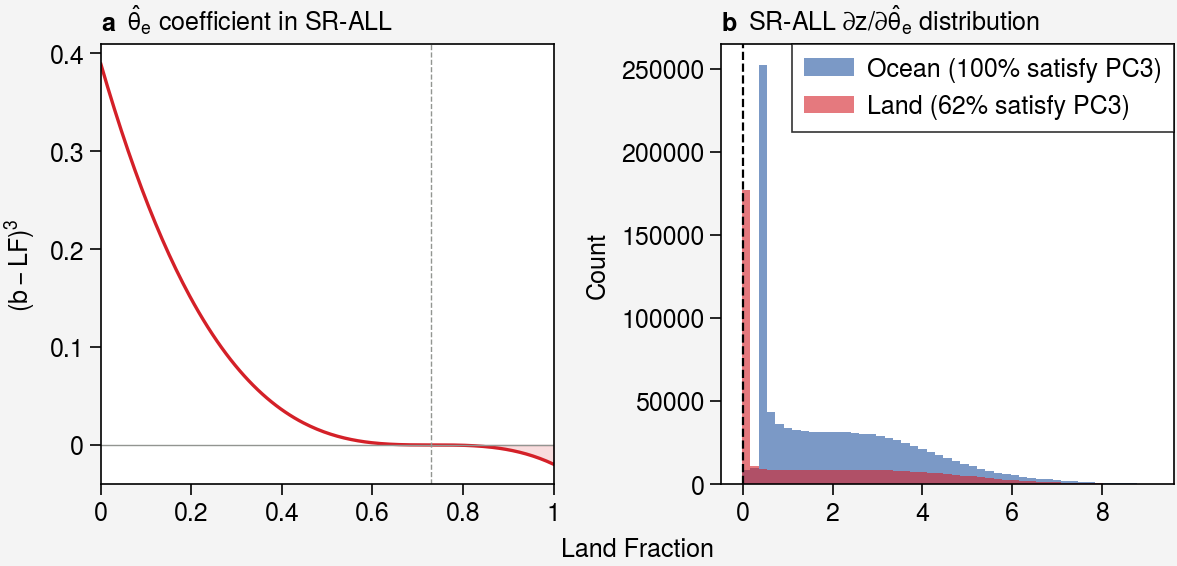

In [6]:
srall = REGISTRY['sr_all_eq']['constants']
derivs = calc_dz('sr_all_eq')
dz_dthetae = derivs['thetae']

fig,axs = pplt.subplots(ncols=2,figwidth=6,refheight=2.2,sharey=False)

lfgrid = np.linspace(0,1,200)
coeff = (srall['b'] - lfgrid)**3
axs[0].plot(lfgrid,coeff,color='#D42028',lw=1.2)
axs[0].fill_between(lfgrid,coeff,0,where=coeff<0,color='#D42028',alpha=0.15)
axs[0].axhline(0,color='gray',lw=0.5)
axs[0].axvline(srall['b'],color='gray',lw=0.5,ls='--')
axs[0].format(xlabel='Land Fraction',ylabel=r'$(b - \mathrm{LF})^3$',
              title=r'$\hat{\theta}_e$ coefficient in SR-ALL')

histbins = np.linspace(np.percentile(dz_dthetae,0.5),np.percentile(dz_dthetae,99.5),50)
oceanpct = np.mean(dz_dthetae[oceanmask] >= 0) * 100
landpct = np.mean(dz_dthetae[landmask] >= 0) * 100
axs[1].hist(dz_dthetae[oceanmask],bins=histbins,color='#2355a1',alpha=0.6,
            label=f'Ocean ({oceanpct:.0f}% satisfy PC3)')
axs[1].hist(dz_dthetae[landmask],bins=histbins,color='#D42028',alpha=0.6,
            label=f'Land ({landpct:.0f}% satisfy PC3)')
axs[1].axvline(0,color='k',lw=0.8,ls='--')
axs[1].legend(loc='ur',ncols=1,fontsize=7)
axs[1].format(xlabel=r'$\partial z / \partial \hat{\theta}_e$',ylabel='Count',
              title=r'SR-ALL $\partial z / \partial \hat{\theta}_e$ distribution')

axs.format(abc=True,titleloc='l',grid=False)
pplt.show()
fig.save('../figs/fig_pc3_diagnostic.jpg')

In [7]:
modelresults = {}
for name in ORDER:
    derivs = calc_dz(name)
    modelresults[name] = {}
    for pcname,pc in CONSTRAINTS.items():
        if name not in pc['equations']:
            modelresults[name][pcname] = {'Land':np.nan,'Ocean':np.nan,'All':np.nan}
            continue
        dz = derivs[pc['target_var']]
        satisfied = dz >= 0 if pc['expected_sign'] >= 0 else dz <= 0
        modelresults[name][pcname] = {
            'Land':np.mean(satisfied[landmask])*100,
            'Ocean':np.mean(satisfied[oceanmask])*100,
            'All':np.mean(satisfied)*100}

srrows = []
for name in ORDER:
    for region in ['Land','Ocean','All']:
        row = {'Model':LABELS[name],'Region':region}
        for pcname in CONSTRAINTS:
            row[PCLABELS[pcname]] = modelresults[name][pcname][region]
        srrows.append(row)

srdf = pd.DataFrame(srrows).set_index(['Model','Region'])
display(srdf.style.format(lambda v:'' if np.isnan(v) else f'{v:.1f}%').set_caption(
    f'SR model physical constraint satisfaction (%, {SPLIT} split, analytical derivatives)'))

### Text SX: SR-BL Partial Derivatives

$$z_{\mathrm{BL}} = (B_L + a)^3 + b$$

$$\frac{\partial z_{\mathrm{BL}}}{\partial B_L} = 3(B_L + a)^2 \geq 0 \quad \text{(PC1 satisfied)}$$

Since the square is always non-negative, PC1 is satisfied for all values of $B_L$ and $a$.

### Text SX: SR-ATM Partial Derivatives

$$z_{\mathrm{ATM}} = a \cdot \left[\max\!\left(\widehat{\mathrm{RH}},\; \widehat{\theta_e} - b\,\widehat{\theta_e^*} - c\right)\right]^3$$

Let $M = \max(\widehat{\mathrm{RH}},\; \widehat{\theta_e} - b\,\widehat{\theta_e^*} - c)$.

**RH branch** ($\widehat{\mathrm{RH}} \geq \widehat{\theta_e} - b\,\widehat{\theta_e^*} - c$):

$$\frac{\partial z}{\partial \widehat{\mathrm{RH}}} = 3a\,\widehat{\mathrm{RH}}^2 \geq 0 \;\text{(PC2)}, \quad \frac{\partial z}{\partial \widehat{\theta_e}} = 0 \;\text{(PC3)}, \quad \frac{\partial z}{\partial \widehat{\theta_e^*}} = 0 \;\text{(PC4)}$$

**Buoyancy branch** ($\widehat{\mathrm{RH}} < \widehat{\theta_e} - b\,\widehat{\theta_e^*} - c$), with $\alpha = \widehat{\theta_e} - b\,\widehat{\theta_e^*} - c$:

$$\frac{\partial z}{\partial \widehat{\mathrm{RH}}} = 0 \;\text{(PC2)}, \quad \frac{\partial z}{\partial \widehat{\theta_e}} = 3a\,\alpha^2 \geq 0 \;\text{(PC3)}, \quad \frac{\partial z}{\partial \widehat{\theta_e^*}} = -3ab\,\alpha^2 \leq 0 \;\text{(PC4)}$$

All constraints satisfied for $a > 0$, $b > 0$.

### Text SX: SR-SFC Partial Derivatives

$$z_{\mathrm{SFC}} = z_{\mathrm{ATM}} + a\,\mathrm{SHF}\,(b - \mathrm{LF}) + c\,\mathrm{LHF}$$

The surface terms depend only on local variables (SHF, LHF, LF), not on the kernel-integrated variables ($\widehat{\mathrm{RH}}$, $\widehat{\theta_e}$, $\widehat{\theta_e^*}$). Therefore:

$$\frac{\partial z_{\mathrm{SFC}}}{\partial \widehat{\mathrm{RH}}} = \frac{\partial z_{\mathrm{ATM}}}{\partial \widehat{\mathrm{RH}}}, \quad \frac{\partial z_{\mathrm{SFC}}}{\partial \widehat{\theta_e}} = \frac{\partial z_{\mathrm{ATM}}}{\partial \widehat{\theta_e}}, \quad \frac{\partial z_{\mathrm{SFC}}}{\partial \widehat{\theta_e^*}} = \frac{\partial z_{\mathrm{ATM}}}{\partial \widehat{\theta_e^*}}$$

All PCs inherited from SR-ATM.

### Text SX: SR-ALL Partial Derivatives

$$z_{\mathrm{ALL}} = z_{\mathrm{ATM}} + (\widehat{\theta_e} + a\,\mathrm{SHF})\,(b - \mathrm{LF})^3 + c$$

$$\frac{\partial z_{\mathrm{ALL}}}{\partial \widehat{\theta_e}} = \frac{\partial z_{\mathrm{ATM}}}{\partial \widehat{\theta_e}} + (b - \mathrm{LF})^3$$

**PC3 violation:** $(b - \mathrm{LF})^3 < 0$ when $\mathrm{LF} > b$. With optimized $b = 0.73$, all land points ($\mathrm{LF} \approx 1$) produce a negative contribution. In the RH branch, where $\partial z_{\mathrm{ATM}} / \partial \widehat{\theta_e} = 0$, this is the sole term, guaranteeing violation. In the buoyancy branch, the positive $3a\,\alpha^2$ partially compensates but does not always dominate.

PC2 and PC4 are unaffected (derivatives identical to SR-ATM).

### Text SX: SR-ALL-PC Partial Derivatives

$$z_{\mathrm{ALL\text{-}PC}} = z_{\mathrm{ATM}} + (\widehat{\theta_e} + a\,\mathrm{SHF})\,(b - \mathrm{LF})^3 - (b - 1)^3\,\widehat{\theta_e} + c$$

$$\frac{\partial z_{\mathrm{ALL\text{-}PC}}}{\partial \widehat{\theta_e}} = \frac{\partial z_{\mathrm{ATM}}}{\partial \widehat{\theta_e}} + \underbrace{(b - \mathrm{LF})^3 - (b - 1)^3}_{\geq\, 0\;\text{for all LF} \in [0,1]}$$

**Proof of non-negativity:** Let $g(\mathrm{LF}) = (b - \mathrm{LF})^3 - (b - 1)^3$. Since $x \mapsto x^3$ is strictly increasing, and $b - \mathrm{LF} \geq b - 1$ for all $\mathrm{LF} \leq 1$, we have $(b - \mathrm{LF})^3 \geq (b - 1)^3$. Therefore $g(\mathrm{LF}) \geq 0$, with equality at $\mathrm{LF} = 1$.

This correction preserves the cubic structure, introduces no discontinuities (unlike a $\max$ clamp), and vanishes exactly at $\mathrm{LF} = 1$. All other partial derivatives are unchanged from SR-ALL, so PC1, PC2, and PC4 remain satisfied.